In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

%matplotlib inline

In [2]:
df_2020 = pd.read_csv('data/df_3x3_2020.csv')
df_2021 = pd.read_csv('data/df_3x3_2021.csv')

In [3]:
df_2020.columns

Index(['system:index', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cell_id', 'cropland',
       'grassland', 'image_count', 'tree_cover', 'water', 'x', 'y', 'year',
       '.geo', 'geometry', 'B11_m1_m1', 'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1',
       'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1',
       'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1',
       'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1',
       'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1',
       'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0',
       'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0',
       'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0',
       'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1',
       'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1',
       'B11_p0_p1', 'B12_p0

In [4]:
# df_2020 = df_2020.drop(columns=['year', 'cell_id', "system:index", "image_count", ".geo", "geometry", *[name for name in df_2021.columns if "B2_" in name or "B3_" in name or "B4_" in name], "x", "y"])
df_2020 = df_2020.drop(columns=['year', 'cell_id', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2020 = df_2020.fillna(df_2020.mean())

# df_2021 = df_2021.drop(columns=['year', 'cell_id', "system:index", "image_count", ".geo", "geometry", *[name for name in df_2021.columns if "B2_" in name or "B3_" in name or "B4_" in name], "x", "y"])
df_2021 = df_2021.drop(columns=['year', 'cell_id', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2021 = df_2021.fillna(df_2021.mean())

In [5]:
# B1, B9, B10

In [6]:
# mean_median_cols = [col for col in df_2020.columns if ('_median' in col)]
# excluded_bands = [col for col in df_2020 if not ('B1_' in col or 'B9_' in col or 'B8A' in col or 'B10_' in col)]

df_2020['vegetation'] = df_2020[['tree_cover', 'cropland', 'grassland']].sum(axis=1)
df_2021['vegetation'] = df_2021[['tree_cover', 'cropland', 'grassland']].sum(axis=1)

target_labels = [
    'built_up',
    'vegetation',
    'water'
]

remaining_target = [
    'bare_sparse_vegetation',
    'tree_cover',
    'grassland',
    'cropland'
]

# sel_col = excluded_bands
# df_2020 = df_2020[sel_col]
# df_2021 = df_2021[sel_col]

In [7]:
df_2020.columns

Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
       'tree_cover', 'water', 'B11_m1_m1', 'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1',
       'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1',
       'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1',
       'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1',
       'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1',
       'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0',
       'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0',
       'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0',
       'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1',
       'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1',
       'B11_p0_p1', 'B12_p0_p1', 'B2_p0_p1', 'B3_p0_p1', 'B4_p0_p1',
       'B5_p0_p1', 'B6_p0_p1', 'B7_p0_p1', 'B

In [8]:
# --- Feature Engineering for df_2020 ---
# Vegetation Indices
df_2020['NDVI'] = (df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + df_2020['B4'] + 1e-8)
# df_2020['EVI'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 6 * df_2020['B4'] - 7.5 * df_2020['B2'] + 1 + 1e-8))
df_2020['EVI2'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 2.4 * df_2020['B4'] + 1 + 1e-8))
df_2020['SAVI'] = ((df_2020['B8'] - df_2020['B4']) * 1.5) / (df_2020['B8'] + df_2020['B4'] + 0.5 + 1e-8)
# df_2020['NDRE'] = (df_2020['B8'] - df_2020['B5']) / (df_2020['B8'] + df_2020['B5'] + 1e-8)
# df_2020['GNDVI'] = (df_2020['B8'] - df_2020['B3']) / (df_2020['B8'] + df_2020['B3'] + 1e-8)

# Urban & Built-up Indices
df_2020['NDBI'] = (df_2020['B11'] - df_2020['B8']) / (df_2020['B11'] + df_2020['B8'] + 1e-8)

# Water & Moisture Indices
df_2020['NDWI'] = (df_2020['B3'] - df_2020['B8']) / (df_2020['B3'] + df_2020['B8'] + 1e-8)
df_2020['MNDWI'] = (df_2020['B3'] - df_2020['B11']) / (df_2020['B3'] + df_2020['B11'] + 1e-8)


# --- Feature Engineering for df_2021 ---
# Vegetation Indices
df_2021['NDVI'] = (df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + df_2021['B4'] + 1e-8)
# df_2021['EVI'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 6 * df_2021['B4'] - 7.5 * df_2021['B2'] + 1 + 1e-8))
df_2021['EVI2'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 2.4 * df_2021['B4'] + 1 + 1e-8))
df_2021['SAVI'] = ((df_2021['B8'] - df_2021['B4']) * 1.5) / (df_2021['B8'] + df_2021['B4'] + 0.5 + 1e-8)
# df_2021['NDRE'] = (df_2021['B8'] - df_2021['B5']) / (df_2021['B8'] + df_2021['B5'] + 1e-8)
# df_2021['GNDVI'] = (df_2021['B8'] - df_2021['B3']) / (df_2021['B8'] + df_2021['B3'] + 1e-8)

# Urban & Built-up Indices
df_2021['NDBI'] = (df_2021['B11'] - df_2021['B8']) / (df_2021['B11'] + df_2021['B8'] + 1e-8)

# Water & Moisture Indices
df_2021['NDWI'] = (df_2021['B3'] - df_2021['B8']) / (df_2021['B3'] + df_2021['B8'] + 1e-8)
df_2021['MNDWI'] = (df_2021['B3'] - df_2021['B11']) / (df_2021['B3'] + df_2021['B11'] + 1e-8)

In [9]:
X_train = df_2020.drop(columns=target_labels + remaining_target)
X_train = X_train.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
# X_train = df_2020[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_train = df_2020[target_labels]

X_test = df_2021.drop(columns=target_labels + remaining_target)
X_test = X_test.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
# X_test = df_2021[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_test = df_2021[target_labels]

In [10]:
X_train.columns, y_train.columns

(Index(['B11', 'B12', 'B2', 'B3', 'B5', 'B6', 'B11_m1_m1', 'B12_m1_m1',
        'B2_m1_m1', 'B3_m1_m1', 'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1',
        'B8_m1_m1', 'B11_p0_m1', 'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1',
        'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1', 'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1',
        'B12_p1_m1', 'B2_p1_m1', 'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1',
        'B7_p1_m1', 'B8_p1_m1', 'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0',
        'B3_m1_p0', 'B4_m1_p0', 'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0',
        'B11_p1_p0', 'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0',
        'B5_p1_p0', 'B6_p1_p0', 'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1',
        'B12_m1_p1', 'B2_m1_p1', 'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1',
        'B7_m1_p1', 'B8_m1_p1', 'B11_p0_p1', 'B12_p0_p1', 'B2_p0_p1',
        'B3_p0_p1', 'B4_p0_p1', 'B5_p0_p1', 'B6_p0_p1', 'B7_p0_p1', 'B8_p0_p1',
        'B11_p1_p1', 'B12_p1_p1', 'B2_p1_p1', 'B3_p1_p1', 'B4_p1_p1',
        'B5_p1_p1', 'B6_p1

In [11]:
def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

    return {
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

In [12]:
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR


models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))]),
    "Lasso Regression": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=0.1, max_iter=10000))]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=5, n_jobs=-1)) # n_jobs=-1 for multiprocessing
    ]),
    # "SVR": Pipeline([
    #         ("scaler", StandardScaler()),
    #         ("svr", MultiOutputRegressor(SVR(kernel='rbf', C=100, epsilon=0.1))),
    #     ]),
    "Random Forest": RandomForestRegressor(
                                            n_estimators=390,
                                            random_state=42,
                                            max_depth=9,
                                            min_samples_split=14,
                                            min_samples_leaf=8,
                                            max_features=0.6061272316154472,
                                            n_jobs=-1
                                           ),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=600,
                                                 learning_rate=0.04475778468557638,
                                                 random_state=42,
                                                 max_depth=10,
                                                 gamma=1.0051560079684305,
                                                 min_child_weight=11,
                                                 reg_alpha=6.714222578424157,
                                                 reg_lambda=0.6964390261386526,
                                                 colsample_bytree=0.6983814307724542,
                                                 subsample=0.6876719545127158,
                                                 n_jobs=-1
                                                 ),
                                    n_jobs=-1
                                    ),
    "MLP Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(220, 118, 133),
            activation='relu',
            solver='adam',
            alpha=0.007440054125108525,
            learning_rate_init=0.0012469151701727857,
            max_iter=500,
            random_state=42,
        ))
    ]),
    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
        ),
        n_jobs=-1
    ),
}

results = []
for name, model in models.items():
    res = evaluate_regression_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)


--- Linear Regression ---
Train R2: 0.6728 | Test R2: 0.6521
Train RMSE: 0.1771 | Test RMSE: 0.1886

--- Ridge Regression ---
Train R2: 0.6715 | Test R2: 0.6502
Train RMSE: 0.1776 | Test RMSE: 0.1891

--- Lasso Regression ---
Train R2: 0.3872 | Test R2: 0.3816
Train RMSE: 0.2220 | Test RMSE: 0.2295

--- KNN ---
Train R2: 0.9089 | Test R2: 0.8352
Train RMSE: 0.1064 | Test RMSE: 0.1459

--- Random Forest ---
Train R2: 0.8652 | Test R2: 0.8102
Train RMSE: 0.1293 | Test RMSE: 0.1565

--- XGBoost ---
Train R2: 0.8938 | Test R2: 0.8377
Train RMSE: 0.1122 | Test RMSE: 0.1447

--- MLP Regressor ---
Train R2: 0.9106 | Test R2: 0.8555
Train RMSE: 0.1009 | Test RMSE: 0.1352

--- Gradient Boosting ---
Train R2: 0.8890 | Test R2: 0.8339
Train RMSE: 0.1189 | Test RMSE: 0.1472



In [13]:
summary_df = pd.DataFrame(results).sort_values(by='Test RMSE', ascending=True)
display(summary_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
6,MLP Regressor,0.100901,0.135212,0.910643,0.855455
5,XGBoost,0.112154,0.144691,0.893768,0.837745
3,KNN,0.106393,0.145903,0.908929,0.835246
7,Gradient Boosting,0.118866,0.147153,0.888975,0.833899
4,Random Forest,0.129319,0.156541,0.865239,0.810163
0,Linear Regression,0.177061,0.188551,0.672799,0.652102
1,Ridge Regression,0.177569,0.189116,0.671489,0.650241
2,Lasso Regression,0.222001,0.229457,0.387203,0.381614


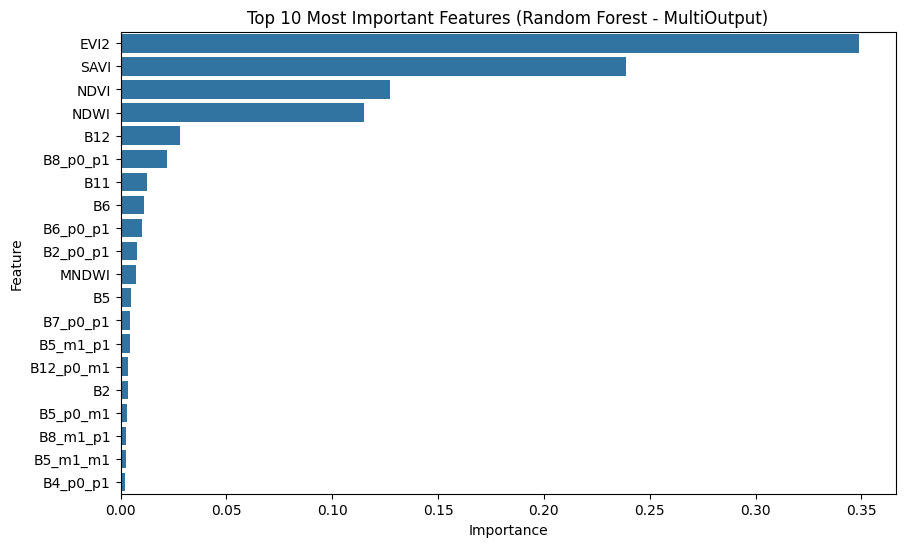

     Feature  Importance
79      EVI2    0.348718
80      SAVI    0.238682
78      NDVI    0.127544
81      NDWI    0.115266
1        B12    0.028233
..       ...         ...
49  B7_p1_p0    0.000126
22  B7_p0_m1    0.000124
31  B7_p1_m1    0.000108
13  B7_m1_m1    0.000094
18  B3_p0_m1    0.000067

[83 rows x 2 columns]


In [15]:
feature_names = X_train.columns
importances = models['Random Forest'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 10 Most Important Features (Random Forest - MultiOutput)')
plt.show()

print(feature_importance_df)

,True_Dominant_Class,Pred_Dominant_Class,Match
0,built_up,vegetation,False
1,built_up,built_up,True
2,built_up,built_up,True
3,built_up,built_up,True
4,built_up,built_up,True


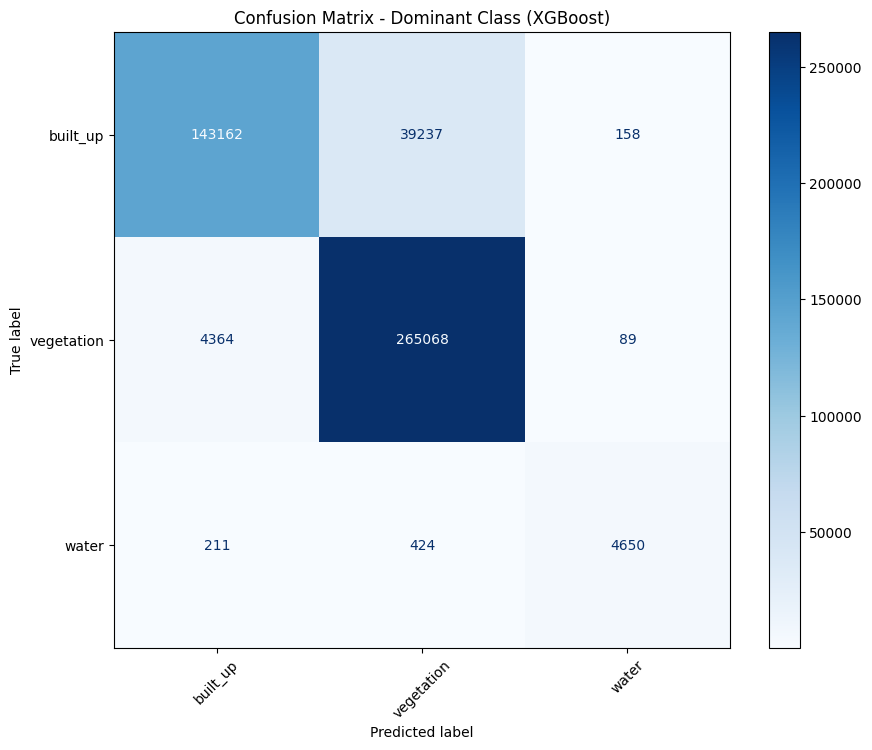

Overall Dominant Class Accuracy: 0.9027


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Use the labels actually used during training (4 labels in your current code)
current_labels = [
    'built_up',
    'vegetation',
    'water'
]

best_model_name = "XGBoost"
y_pred_array = models[best_model_name].predict(X_test)

# 2. Create DataFrame with the matching 4 columns
y_pred_df = pd.DataFrame(y_pred_array, columns=current_labels)

# 3. Get dominant classes
true_dominant = y_test[current_labels].idxmax(axis=1).reset_index(drop=True)
pred_dominant = y_pred_df.idxmax(axis=1)

# 4. Build comparison table
comparison_df = pd.DataFrame({
    'True_Dominant_Class': true_dominant,
    'Pred_Dominant_Class': pred_dominant
})
comparison_df['Match'] = comparison_df['True_Dominant_Class'] == comparison_df['Pred_Dominant_Class']

# 5. Output results
display(comparison_df.head(5))

# 6. Generate Confusion Matrix
cm = confusion_matrix(true_dominant, pred_dominant, labels=current_labels)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=current_labels)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())
plt.title(f'Confusion Matrix - Dominant Class ({best_model_name})')
plt.show()

accuracy = comparison_df['Match'].mean()
print(f"Overall Dominant Class Accuracy: {accuracy:.4f}")